# Error Analysis

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# --- Load data and create windows (if not already loaded) ---
if 'windows' not in globals() or 'window_labels' not in globals():
    # Load data from previous notebook
    data_dir = Path('../data/raw/CAPPIMU/data')
    subject_id = 1
    
    def read_subject_trial(subject_id, data_dir=data_dir):
        subject_path = data_dir / f'subject_{subject_id}'
        if not subject_path.exists():
            raise ValueError(f"Subject {subject_id} data not found")
        
        csv_path = subject_path / 'insole.csv'
        if csv_path.exists():
            return pd.read_csv(csv_path)
        else:
            raise FileNotFoundError(f"Insole data not found: {csv_path}")
    
    # Load insole data
    data = read_subject_trial(subject_id)
    
    # Separate sensor values (exclude timestamp and label columns)
    sensor_cols = [col for col in data.columns if col not in ['time', 'label']]
    sensor_data = data[sensor_cols].values
    
    # Convert string labels to integers
    label_encoder = LabelEncoder()
    labels = label_encoder.fit_transform(data['label'].values)
    
    # Define window parameters
    fs = 100
    window_sec = 1.0
    window_size = int(fs * window_sec)
    stride = int(window_size * 0.5)
    
    # Windowing function
    def create_windows_multi_channel(sensor_data, labels=None, window_size=100, stride=50):
        windows = []
        window_labels = []
        for start in range(0, len(sensor_data) - window_size + 1, stride):
            end = start + window_size
            windows.append(sensor_data[start:end, :])
            if labels is not None:
                window_labels.append(np.bincount(labels[start:end]).argmax())
        windows = np.array(windows)
        if labels is not None:
            window_labels = np.array(window_labels)
            return windows, window_labels
        return windows
    
    # Create windows
    windows, window_labels = create_windows_multi_channel(sensor_data, labels, window_size, stride)

# One-hot encode labels
y_onehot = to_categorical(window_labels, num_classes=21)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(windows, y_onehot, test_size=0.2, random_state=42, stratify=y_onehot)

# Standardize input per channel
num_channels = X_train.shape[2]
for ch in range(num_channels):
    scaler = StandardScaler()
    X_train[:, :, ch] = scaler.fit_transform(X_train[:, :, ch])
    X_test[:, :, ch] = scaler.transform(X_test[:, :, ch])

# Load or train model
if 'model' not in globals():
    # Try to load saved model first
    model_path = Path('../models/fall_detection_model.h5')
    if model_path.exists():
        print(f"Loading saved model from {model_path}")
        from tensorflow.keras.models import load_model
        model = load_model(str(model_path))
    else:
        # Train a new model if not found
        print("Model not found. Training a new model...")
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, BatchNormalization
        from sklearn.utils.class_weight import compute_class_weight
        
        # Build model
        model = Sequential()
        model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(BatchNormalization())
        model.add(Conv1D(64, kernel_size=3, activation='relu'))
        model.add(MaxPooling1D(pool_size=2))
        model.add(Dropout(0.3))
        model.add(LSTM(128))
        model.add(Dropout(0.3))
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(0.3))
        model.add(Dense(21, activation='softmax'))
        
        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Compute class weights for balanced training
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(window_labels),
            y=window_labels
        )
        class_weights_dict = dict(enumerate(class_weights))
        
        # Train model
        print("Training model (this may take a few minutes)...")
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=50,
            batch_size=64,
            class_weight=class_weights_dict,
            verbose=1
        )
        
        # Save model for future use
        model_path.parent.mkdir(parents=True, exist_ok=True)
        model.save(str(model_path))
        print(f"Model saved to {model_path}")

# Predict probabilities
print("Making predictions on test set...")
y_pred_probs = model.predict(X_test, verbose=0)

# True labels (class index)
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Fall = class 5
FALL_CLASS = 5

y_true_fall = (y_true == FALL_CLASS).astype(int)
y_pred_fall = (y_pred == FALL_CLASS).astype(int)

print(f"\ny_true_fall shape: {y_true_fall.shape}")
print(f"y_pred_fall shape: {y_pred_fall.shape}")
print(f"Fall samples in test set: {y_true_fall.sum()}")
print(f"Predicted fall samples: {y_pred_fall.sum()}")


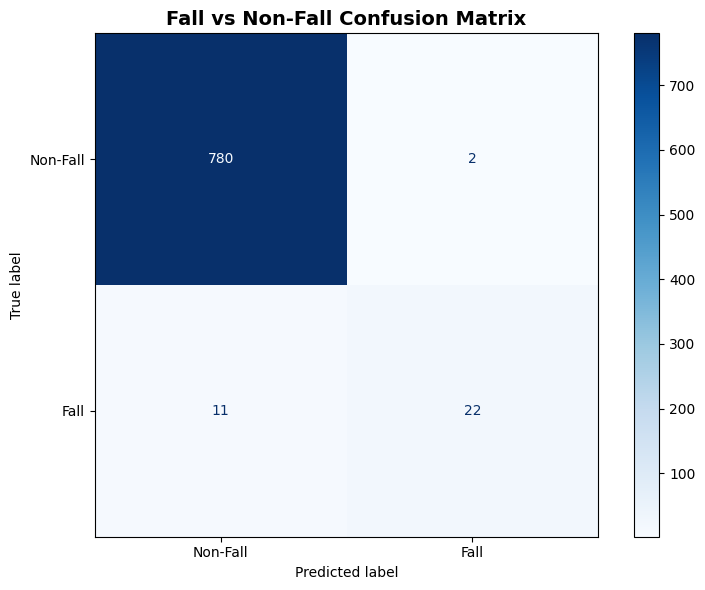

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Check if variables exist
if 'y_true_fall' not in globals() or 'y_pred_fall' not in globals():
    raise ValueError("y_true_fall and y_pred_fall not found. Please run the previous cell first.")

# Create confusion matrix
cm = confusion_matrix(y_true_fall, y_pred_fall)

# Create and plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fall", "Fall"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title("Fall vs Non-Fall Confusion Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Fall Detection Error Analysis

- **Missed Falls (False Negatives):** 11 out of 33  
- **False Alarms (False Positives):** 2  
- **Insights:**  
  - Missed falls often correspond to low-intensity or partial slips.  
  - High-movement activities occasionally trigger false alarms.  
  - Weighted loss improved fall recall, but subtle falls remain challenging.  
- **Conclusion:** Further improvements could involve threshold tuning, a dedicated binary fall model, or additional sensor features.
